In [1]:
import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from utils.utils import read_root_file, read_lumi_data, prepare_data, weighted_average

%load_ext autoreload
%autoreload 2

Welcome to JupyROOT 6.26/10


In [2]:
# Step 1: Read ROOT file and apply cuts
# cuts = {"B_J1_mass": (2.7, 3.5), "B_Mu1_pt": (7, None), "B_Mu2_pt": (7, None)}  # Apply J/ψ mass cut
cuts = {}
# root_file_path = "../preselection/parkingDoubleMuonLowMass/2023/PDMLM0_mm_2023D_v1_HLT_Dimuon0_Jpsi3p5_Muon2_v9.root"
root_file_path = "../../preselection/parkingDoubleMuonLowMass/2023/v2/PDMLM_mm_2023D_v2.root"
run, lumiblock, mass = read_root_file(root_file_path, cuts)

lumi_file = '../../preselection/parkingDoubleMuonLowMass/2024/lumi_normtagBRIL_PDMLM0_2023D.csv'
lumi_df = read_lumi_data(lumi_file)

# event_y, event_y_error, lumi_y, pileup_y, x_labels, nlumis, prescale_lines = prepare_data(run, lumiblock, mass_range=(2.85, 3.35), mass=mass, lumi_df=lumi_df, count_method='direct')
# event_y, event_y_error, lumi_y, pileup_y, x_labels, nlumis, prescale_lines = prepare_data(run, lumiblock, mass_range=(2.7, 3.5), mass=mass, lumi_df=lumi_df, count_method='fit')

Available branches: ['Run', 'LumiBlock', 'Event', 'B_J1_mass', 'B_J1_pt', 'B_Mu1_pt', 'B_Mu2_pt', 'B_Mu1_eta', 'B_Mu2_eta']


MemoryError: Unable to allocate 1.50 GiB for an array with shape (200980704,) and data type int64

In [3]:
# Assuming all arrays are of equal length or can logically align row-wise
df = pd.DataFrame({
    'event_y': event_y,
    'event_y_error': event_y_error,
    'lumi_y': lumi_y,
    'pileup_y': pileup_y,
    'x_labels': x_labels,
    'nlumis': nlumis
})
df = df[df['nlumis']>40]
df = df[df['event_y']>500]
df.reset_index(drop=True, inplace=True)

del event_y, event_y_error, lumi_y, pileup_y, x_labels, nlumis
# df['event_y'] = df['event_y'] *scale_factor

In [4]:
df

,event_y,event_y_error,lumi_y,pileup_y,x_labels,nlumis
0,614,24.779023,6.526582,32.428,369927_100,50
1,874,29.563491,8.925253,44.440,369927_150,50
2,1080,32.863353,11.621136,57.996,369927_200,50
3,1120,33.466401,12.451120,62.214,369927_250,50
4,1178,34.322005,12.575516,62.834,369927_300,50
...,...,...,...,...,...,...
443,16931,130.119176,178.992605,23.164,370580_2600,50
444,16936,130.138388,176.779674,22.682,370580_2650,50
445,16483,128.386136,173.879850,22.224,370580_2700,50
446,16183,127.212421,170.802503,21.796,370580_2750,50


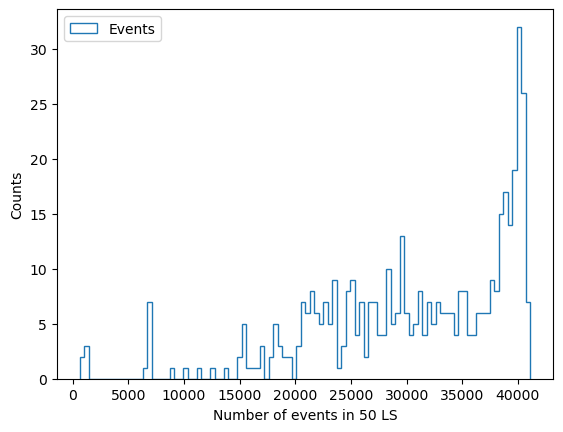

In [5]:
plt.hist(df['event_y'], bins=100, histtype='step', label='Events')
# plt.hist(df['nlumis'], bins=100, histtype='step', label='Nlumis')
plt.xlabel('Number of events in 50 LS')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend()

In [6]:
df['Ratio'] = df['event_y'] / df['lumi_y'] 
df['Ratio_err'] = df['Ratio'] * np.sqrt((df['event_y_error']/df['event_y'])**2 + 0.013**2)

In [7]:
df

,event_y,event_y_error,lumi_y,pileup_y,x_labels,nlumis,Ratio,Ratio_err
0,614,24.779023,6.526582,32.428,369927_100,50,94.076810,3.988751
1,874,29.563491,8.925253,44.440,369927_150,50,97.924399,3.548547
2,1080,32.863353,11.621136,57.996,369927_200,50,92.934117,3.075159
3,1120,33.466401,12.451120,62.214,369927_250,50,89.951750,2.931181
4,1178,34.322005,12.575516,62.834,369927_300,50,93.674086,2.988624
...,...,...,...,...,...,...,...,...
443,16931,130.119176,178.992605,23.164,370580_2600,50,94.590500,1.428483
444,16936,130.138388,176.779674,22.682,370580_2650,50,95.802870,1.446737
445,16483,128.386136,173.879850,22.224,370580_2700,50,94.795343,1.436606
446,16183,127.212421,170.802503,21.796,370580_2750,50,94.746855,1.439383


In [8]:
df[['run', 'lumiblock']] = df['x_labels'].str.split('_', expand=True)
df['run'] = df['run'].astype(int)
df['lumiblock'] = df['lumiblock'].astype(int)

In [9]:
ROOT.gROOT.SetBatch(True)

fit_run = []
fit_slope = []
fit_slope_err = []
fit_const = []
fit_const_err = []

for run_number, group in df.groupby('run'):
    # ignore short runs
    if len(group) < 10:
        continue

    # Prepare data
    x = group['lumi_y'].values.astype(float)
    y = group['Ratio'].values.astype(float)
    y_err = group['Ratio_err'].values.astype(float)
    x_err = np.zeros_like(x)

    # Create TGraphErrors
    graph = ROOT.TGraphErrors(len(x), x, y, x_err, y_err)
    graph.SetTitle(f"Run {run_number}")
    graph.GetXaxis().SetTitle("Instantaneous Luminosity in 50 LS (nb^{-1})")
    graph.GetYaxis().SetTitle("Ratio J/#psi count to Instantaneous Luminosity in 50 LS")
    graph.SetMarkerStyle(20)
    graph.SetMarkerSize(1)

    # Fit with linear function
    fit_func = ROOT.TF1("fit_func", "pol1", min(x), max(x))
    fit_result = graph.Fit(fit_func, "QS")  # Q: quiet, S: returns fit result

    # Get fit parameters and stats
    p0 = fit_func.GetParameter(0)
    p0_err = fit_func.GetParError(0)
    p1 = fit_func.GetParameter(1)
    p1_err = fit_func.GetParError(1)
    chi2 = fit_func.GetChisquare()
    ndf = fit_func.GetNDF()
    red_chi2 = chi2 / ndf if ndf != 0 else 0

    fit_run.append(run_number)
    fit_slope.append(p1)
    fit_slope_err.append(p1_err)
    fit_const.append(p0)
    fit_const_err.append(p0_err)

    # Create canvas and draw
    canvas = ROOT.TCanvas(f"c_{run_number}", f"Run {run_number}", 800, 600)
    canvas.SetLeftMargin(0.15)  # Increase left margin for y-label
    graph.Draw("AP")
    fit_func.Draw("Same")

    # Prepare fit info box
    stats_text = ROOT.TPaveText(0.35, 0.75, 0.89, 0.9, "NDC")
    stats_text.SetFillColor(0)  # Transparent fill
    stats_text.SetFillStyle(0)  # Transparent fill style
    stats_text.SetBorderSize(0) # Remove border
    stats_text.SetTextAlign(13)
    stats_text.SetTextSize(0.030)  # Adjust text size if needed
    stats_text.AddText(f"y = ({p0:.3e} #pm {p0_err:.1e}) + ({p1:.3e} #pm {p1_err:.1e}) * x")
    stats_text.AddText(f"#chi^{{2}} / ndf = {chi2:.2f} / {ndf} = {red_chi2:.2f}")
    stats_text.Draw()

    canvas.Update()
    canvas.SaveAs(f"plots/ratio_fits/fit_run_{run_number}.png")


Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_369956.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_369978.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370102.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370129.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370144.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370169.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370175.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370293.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370294.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370300.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_370307.png has been created
Info in <TCanvas::Print>: png fi

In [10]:
summary_df = pd.DataFrame({
    'fit_run': fit_run,
    'fit_slope': fit_slope,
    'fit_slope_err': fit_slope_err,
    'fit_const': fit_const,
    'fit_const_err': fit_const_err,
})

In [11]:
avg_slope, avg_slope_err = weighted_average(
    summary_df['fit_slope'].values, 
    summary_df['fit_slope_err'].values
)


avg_const, avg_const_err = weighted_average(
    summary_df['fit_const'].values, 
    summary_df['fit_const_err'].values
)

<function matplotlib.pyplot.plot(*args, scalex=True, scaley=True, data=None, **kwargs)>

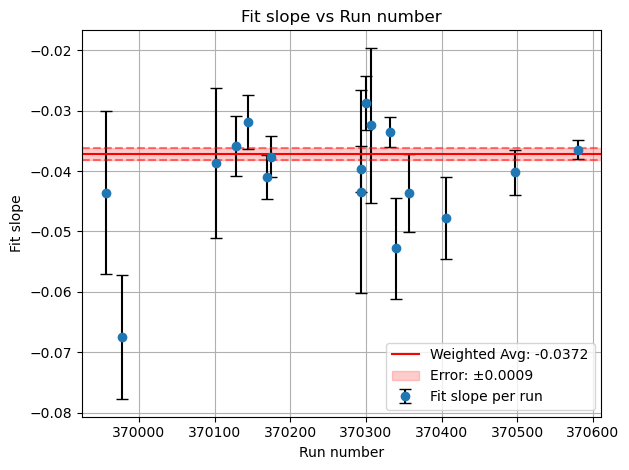

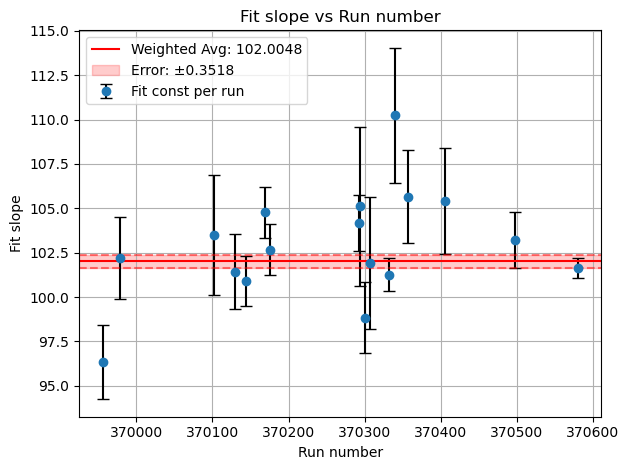

<Figure size 640x480 with 0 Axes>

In [12]:
plt.errorbar(
    summary_df['fit_run'],
    summary_df['fit_slope'],
    yerr=summary_df['fit_slope_err'],
    fmt='o',
    ecolor='black',
    capsize=4,
    label='Fit slope per run'
)
# Add the weighted average as a horizontal line
plt.axhline(y=avg_slope, color='r', linestyle='-', label=f'Weighted Avg: {avg_slope:.4f}')

# Add horizontal lines for the error bounds (optional)
plt.axhline(y=avg_slope+avg_slope_err, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=avg_slope-avg_slope_err, color='r', linestyle='--', alpha=0.5)

# Add shaded error region (alternative to dashed lines)
plt.axhspan(avg_slope-avg_slope_err, avg_slope+avg_slope_err, 
            alpha=0.2, color='r', label=f'Error: ±{avg_slope_err:.4f}')

plt.xlabel('Run number')
plt.ylabel('Fit slope')
plt.title('Fit slope vs Run number')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig('summary.png')

plt.figure()
plt.errorbar(
    summary_df['fit_run'],
    summary_df['fit_const'],
    yerr=summary_df['fit_const_err'],
    fmt='o',
    ecolor='black',
    capsize=4,
    label='Fit const per run'
)
# Add the weighted average as a horizontal line
plt.axhline(y=avg_const, color='r', linestyle='-', label=f'Weighted Avg: {avg_const:.4f}')

# Add horizontal lines for the error bounds (optional)
plt.axhline(y=avg_const+avg_const_err, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=avg_const-avg_const_err, color='r', linestyle='--', alpha=0.5)

# Add shaded error region (alternative to dashed lines)
plt.axhspan(avg_const-avg_const_err, avg_const+avg_const_err, 
            alpha=0.2, color='r', label=f'Error: ±{avg_const_err:.4f}')

plt.xlabel('Run number')
plt.ylabel('Fit slope')
plt.title('Fit slope vs Run number')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig('summary.png')


plt.figure()
plt.plot

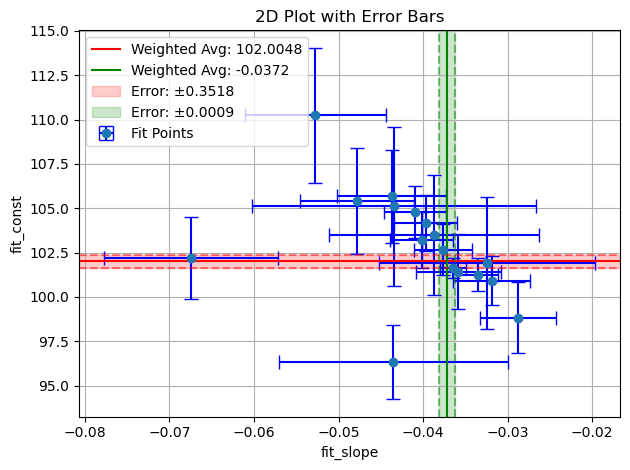

In [13]:
plt.errorbar(fit_slope, fit_const, 
             xerr=fit_slope_err, yerr=fit_const_err, 
             fmt='o', ecolor='blue', capsize=5, label='Fit Points')

# Label axes
plt.xlabel('fit_slope')
plt.ylabel('fit_const')
plt.title('2D Plot with Error Bars')
plt.grid(True)
plt.axhline(y=avg_const, color='r', linestyle='-', label=f'Weighted Avg: {avg_const:.4f}')
plt.axvline(x=avg_slope, color='g', linestyle='-', label=f'Weighted Avg: {avg_slope:.4f}')
plt.axhline(y=avg_const+avg_const_err, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=avg_const-avg_const_err, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=avg_slope+avg_slope_err, color='g', linestyle='--', alpha=0.5)
plt.axvline(x=avg_slope-avg_slope_err, color='g', linestyle='--', alpha=0.5)
plt.axhspan(avg_const-avg_const_err, avg_const+avg_const_err,
            alpha=0.2, color='r', label=f'Error: ±{avg_const_err:.4f}')
plt.axvspan(avg_slope-avg_slope_err, avg_slope+avg_slope_err,
            alpha=0.2, color='g', label=f'Error: ±{avg_slope_err:.4f}')

plt.legend()
# plt.xlim(-0.010, -0.00)
# plt.ylim(12, 14.5)
plt.tight_layout()
plt.show()

In [14]:
# scale events to match lumi
scale_factor = sum(df['lumi_y']) / sum(df['event_y'])
scaled_event_y = [y * scale_factor for y in df['event_y']]
scale_factor

0.011355487909134918

In [15]:
df

,event_y,event_y_error,lumi_y,pileup_y,x_labels,nlumis,Ratio,Ratio_err,run,lumiblock
0,614,24.779023,6.526582,32.428,369927_100,50,94.076810,3.988751,369927,100
1,874,29.563491,8.925253,44.440,369927_150,50,97.924399,3.548547,369927,150
2,1080,32.863353,11.621136,57.996,369927_200,50,92.934117,3.075159,369927,200
3,1120,33.466401,12.451120,62.214,369927_250,50,89.951750,2.931181,369927,250
4,1178,34.322005,12.575516,62.834,369927_300,50,93.674086,2.988624,369927,300
...,...,...,...,...,...,...,...,...,...,...
443,16931,130.119176,178.992605,23.164,370580_2600,50,94.590500,1.428483,370580,2600
444,16936,130.138388,176.779674,22.682,370580_2650,50,95.802870,1.446737,370580,2650
445,16483,128.386136,173.879850,22.224,370580_2700,50,94.795343,1.436606,370580,2700
446,16183,127.212421,170.802503,21.796,370580_2750,50,94.746855,1.439383,370580,2750


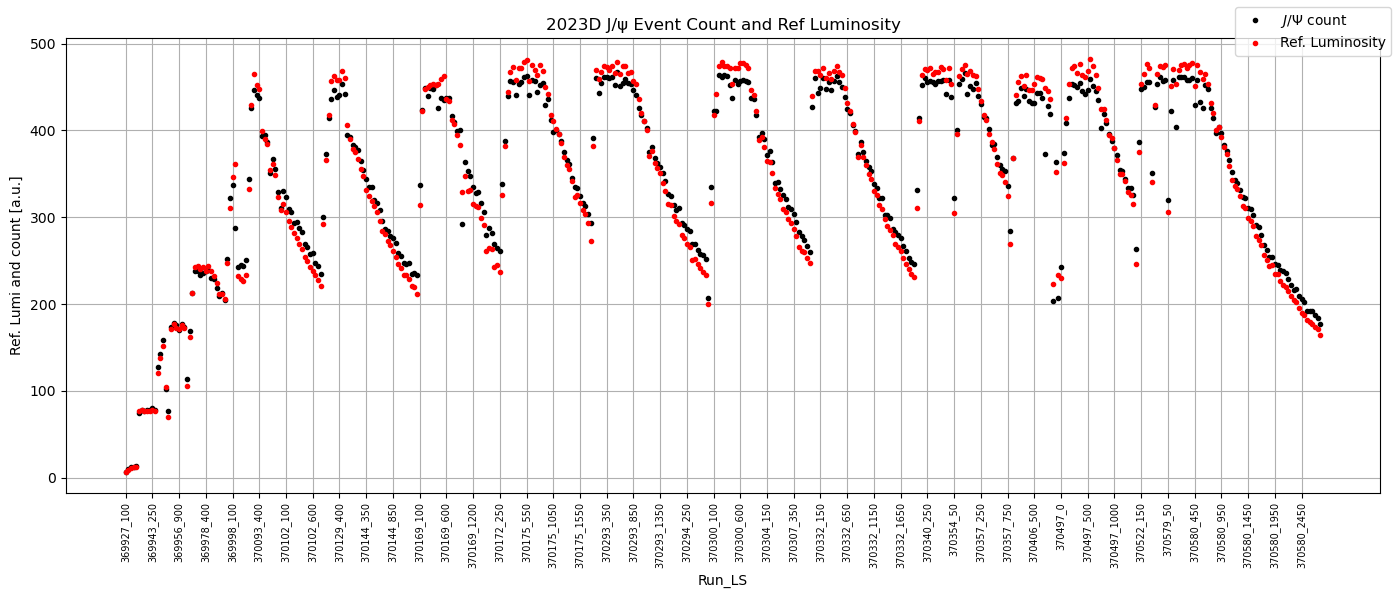

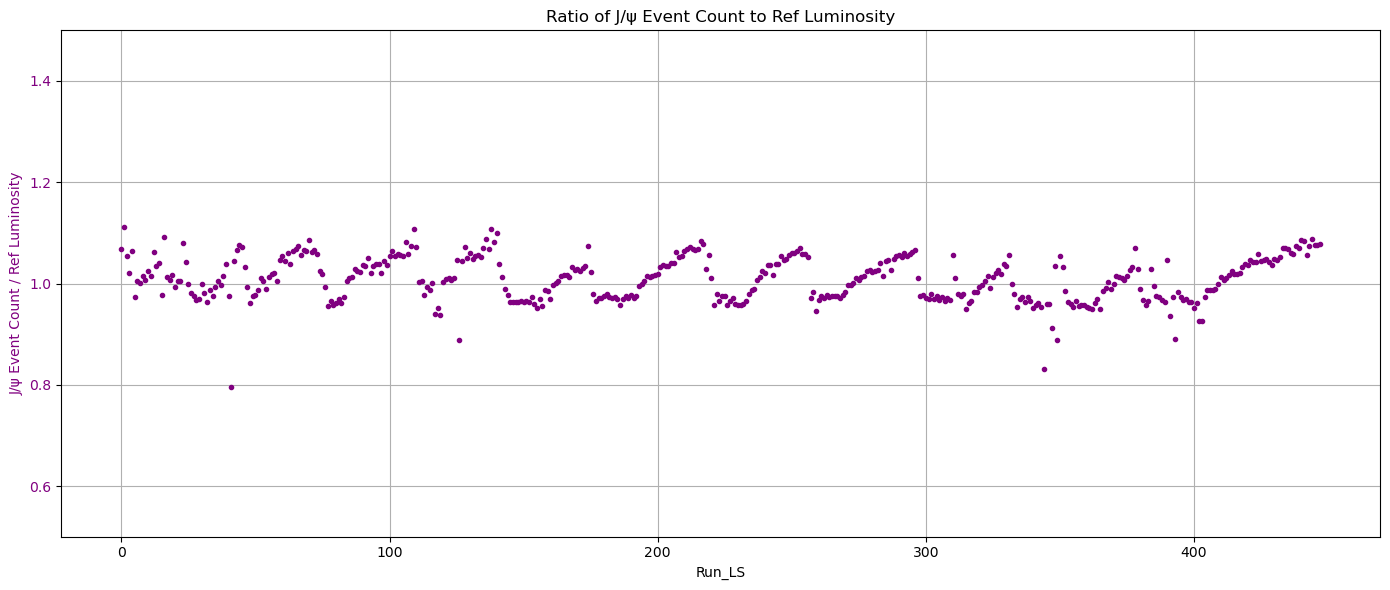

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(range(len(df['x_labels'])), scaled_event_y, label="$J/ \Psi$ count", color="black", marker='.', linestyle='none')
ax1.plot(range(len(df['x_labels'])), df['lumi_y'], label="Ref. Luminosity", color="red", marker='.', linestyle='none')
ax1.set_xlabel("Run_LS")
ax1.set_ylabel("Ref. Lumi and count [a.u.]", color="black")
ax1.tick_params(axis='y', labelcolor="black")

ax1.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax1.get_xticks() if 0 <= tick < len(df)]
ax1.set_xticks(visible_ticks)
ax1.set_xticklabels(df.loc[visible_ticks, 'x_labels'], rotation=90, fontsize=7)

ax1.grid(True)
fig.legend(loc='upper right')
plt.title("2023D J/ψ Event Count and Ref Luminosity")
fig.tight_layout()
plt.savefig("Jpsi.png", dpi=300)

# Compute ratio safely (avoid division by zero)
event_y_arr = np.array(scaled_event_y)
lumi_y_arr = np.array(df['lumi_y'])
ratio = np.zeros_like(lumi_y_arr)
nonzero_mask = event_y_arr != 0
ratio[nonzero_mask] = event_y_arr[nonzero_mask] / lumi_y_arr[nonzero_mask]

# Plot the ratio
fig2, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(range(len(df['x_labels'])), ratio, color="purple", marker='.', linestyle='none')
ax3.set_xlabel("Run_LS")
ax3.set_ylabel("J/ψ Event Count / Ref Luminosity", color="purple")
ax3.tick_params(axis='y', labelcolor="purple")

ax1.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax1.get_xticks() if 0 <= tick < len(df)]
ax1.set_xticks(visible_ticks)
ax1.set_xticklabels(df.loc[visible_ticks, 'x_labels'], rotation=90, fontsize=7)

ax3.grid(True)
plt.title("Ratio of J/ψ Event Count to Ref Luminosity")
plt.ylim(0.5, 1.5)
fig2.tight_layout()
plt.savefig("Jpsi_ratio.png", dpi=300)  

In [17]:
df

,event_y,event_y_error,lumi_y,pileup_y,x_labels,nlumis,Ratio,Ratio_err,run,lumiblock
0,614,24.779023,6.526582,32.428,369927_100,50,94.076810,3.988751,369927,100
1,874,29.563491,8.925253,44.440,369927_150,50,97.924399,3.548547,369927,150
2,1080,32.863353,11.621136,57.996,369927_200,50,92.934117,3.075159,369927,200
3,1120,33.466401,12.451120,62.214,369927_250,50,89.951750,2.931181,369927,250
4,1178,34.322005,12.575516,62.834,369927_300,50,93.674086,2.988624,369927,300
...,...,...,...,...,...,...,...,...,...,...
443,16931,130.119176,178.992605,23.164,370580_2600,50,94.590500,1.428483,370580,2600
444,16936,130.138388,176.779674,22.682,370580_2650,50,95.802870,1.446737,370580,2650
445,16483,128.386136,173.879850,22.224,370580_2700,50,94.795343,1.436606,370580,2700
446,16183,127.212421,170.802503,21.796,370580_2750,50,94.746855,1.439383,370580,2750


In [18]:
avg_slope, avg_const

(-0.037179272835224285, 102.00481868827472)

In [19]:
# avg_slope = -4.7E-3
# avg_const = 12.8 
# avg_slope = -4.4E-3
# avg_const = 11.28

predicted_lumi_y = []
for i, y in enumerate(df['event_y']):
        # Calculate the predicted event count using the linear fit
        predicted_count = (-avg_const + np.sqrt(avg_const**2 + 4 * avg_slope * y) ) / (2 * avg_slope)
        predicted_lumi_y.append(predicted_count)

# scale predicted lumi to match lumi
scale_factor_pred = sum(df['lumi_y']/sum(predicted_lumi_y))
scaled_predicted_lumi_y = [y * scale_factor_pred for y in predicted_lumi_y]

In [20]:
scale_factor_pred

0.9953265815450998

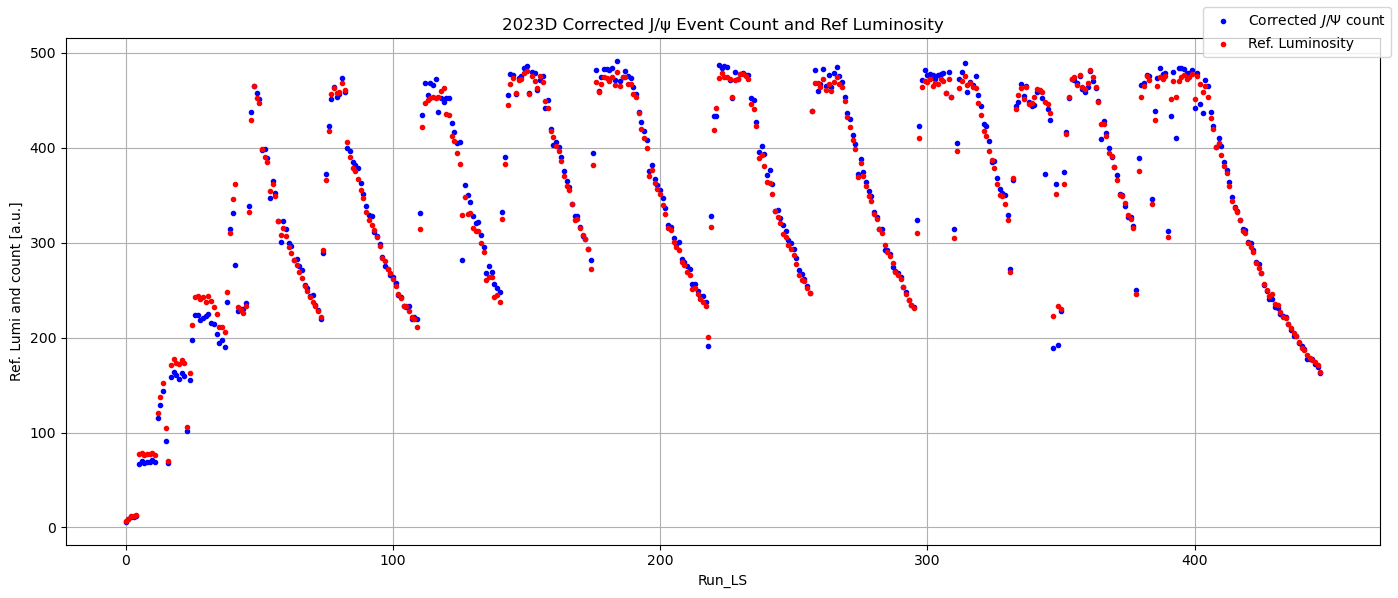

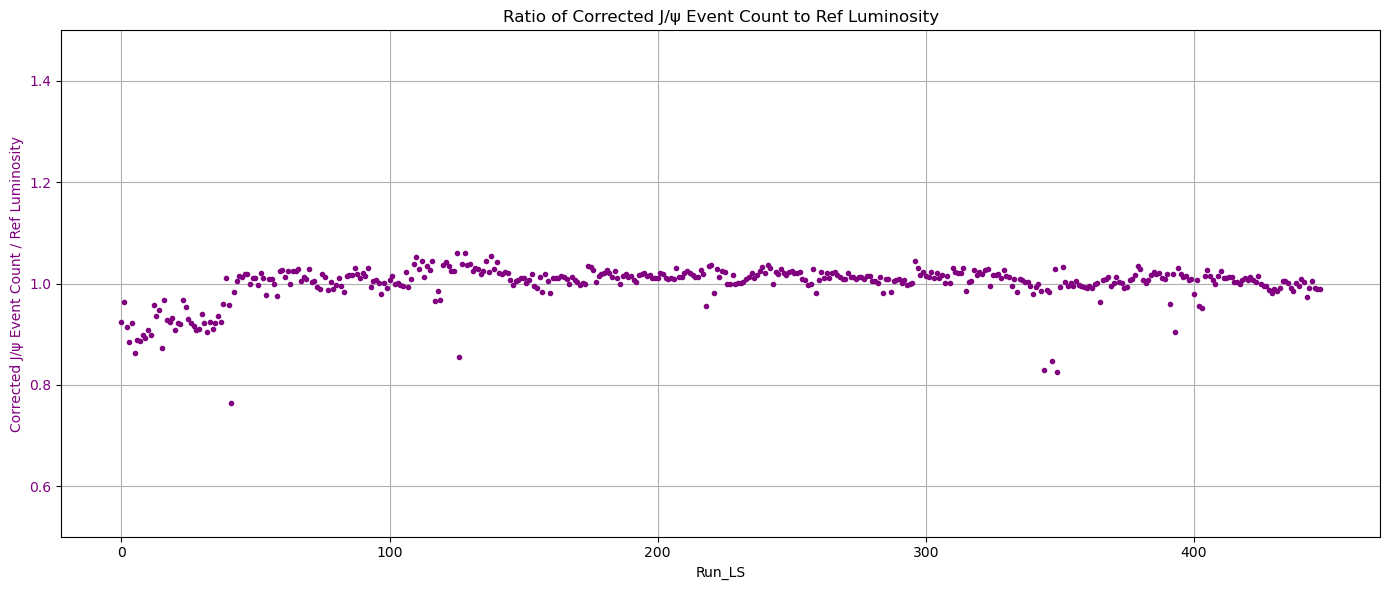

In [21]:
fig3, ax4 = plt.subplots(figsize=(14, 6))

# ax4.plot(range(len(df['x_labels'])), scaled_event_y, label="$J/ \Psi$ count", color="black", marker='.', linestyle='none')
ax4.plot(range(len(df['x_labels'])), predicted_lumi_y, label="Corrected $J/ \Psi$ count", color="blue", marker='.', linestyle='none')
ax4.plot(range(len(df['x_labels'])), df['lumi_y'], label="Ref. Luminosity", color="red", marker='.', linestyle='none')
ax4.set_xlabel("Run_LS")
ax4.set_ylabel("Ref. Lumi and count [a.u.]", color="black")
ax4.tick_params(axis='y', labelcolor="black")

ax1.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax1.get_xticks() if 0 <= tick < len(df)]
ax1.set_xticks(visible_ticks)
ax1.set_xticklabels(df.loc[visible_ticks, 'x_labels'], rotation=90, fontsize=7)

ax4.grid(True)
fig3.legend(loc='upper right')
plt.title("2023D Corrected J/ψ Event Count and Ref Luminosity")
fig3.tight_layout()
plt.savefig("Jpsi_after.png", dpi=300)


# Compute ratio safely (avoid division by zero)
event_y_arr = np.array(predicted_lumi_y)
lumi_y_arr = np.array(df['lumi_y'])
ratio_corr = event_y_arr / lumi_y_arr
# ratio = np.zeros_like(lumi_y_arr)
# nonzero_mask = event_y_arr != 0
# ratio[nonzero_mask] = event_y_arr[nonzero_mask] / lumi_y_arr[nonzero_mask]

# Plot the ratio
fig4, ax5 = plt.subplots(figsize=(14, 6))
ax5.plot(range(len(df['x_labels'])), ratio_corr, color="purple", marker='.', linestyle='none')
ax5.set_xlabel("Run_LS")
ax5.set_ylabel("Corrected J/ψ Event Count / Ref Luminosity", color="purple")
ax5.tick_params(axis='y', labelcolor="purple")

ax1.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax1.get_xticks() if 0 <= tick < len(df)]
ax1.set_xticks(visible_ticks)
ax1.set_xticklabels(df.loc[visible_ticks, 'x_labels'], rotation=90, fontsize=7)

ax5.grid(True)
plt.title("Ratio of Corrected J/ψ Event Count to Ref Luminosity")
plt.ylim(0.5, 1.5)
fig4.tight_layout()
plt.savefig("Jpsi_ratio_after.png", dpi=300)  

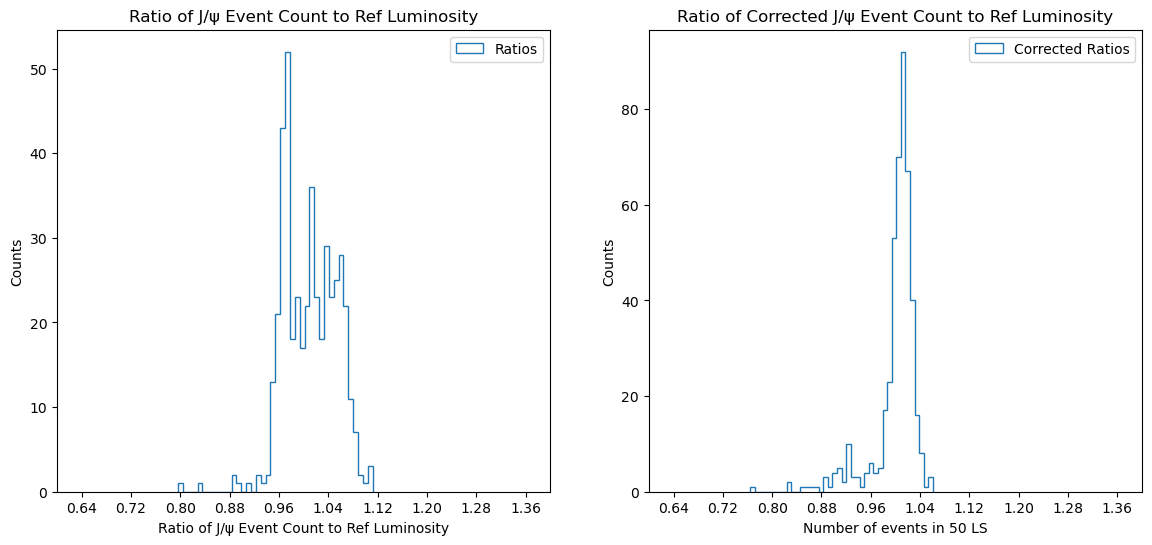

In [22]:
# plot the two ratio histograms side by side with rms included
fig5, (ax6, ax7) = plt.subplots(1, 2, figsize=(14, 6))
ax6.hist(ratio, bins=40, histtype='step', label='Ratios')
ax6.set_xlabel('Ratio of J/ψ Event Count to Ref Luminosity')
ax6.set_ylabel('Counts')
ax6.legend()
ax7.hist(ratio_corr, bins=40, histtype='step', label='Corrected Ratios')
ax7.set_xlabel('Number of events in 50 LS')
ax7.set_ylabel('Counts')
ax7.legend()
ax6.set_title("Ratio of J/ψ Event Count to Ref Luminosity")
ax7.set_title("Ratio of Corrected J/ψ Event Count to Ref Luminosity")
ax6.xaxis.set_major_locator(ticker.MaxNLocator(50))
ax7.xaxis.set_major_locator(ticker.MaxNLocator(50))
ax6.set_xlim(0.6, 1.4)
ax7.set_xlim(0.6, 1.4)
ax6.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax7.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax6.xaxis.set_major_locator(ticker.MaxNLocator(10))
ax7.xaxis.set_major_locator(ticker.MaxNLocator(10)) 

In [23]:
# now make the luminosity weighted histogram of the ratios
# weighted histogram
def weighted_histogram(data, weights, bins=100):
    hist, bin_edges = np.histogram(data, bins=bins, weights=weights)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return hist, bin_centers
# Calculate weights
weights = np.ones_like(ratio) / len(ratio)
# Calculate weighted histogram
hist, bin_centers = weighted_histogram(ratio, weights, bins=100)
# Plot the weighted histogram
ax6.plot(bin_centers, hist, label='Weighted Ratios', color='orange')
# Calculate weights
weights_corr = np.ones_like(ratio_corr) / len(ratio_corr)
# Calculate weighted histogram
hist_corr, bin_centers_corr = weighted_histogram(ratio_corr, weights_corr, bins=100)
# Plot the weighted histogram
ax7.plot(bin_centers_corr, hist_corr, label='Weighted Corrected Ratios', color='orange')
ax6.legend()
ax7.legend()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>